In [2]:
# ==========================================================
#                 Universidad Franz Tamayo
# ----------------------------------------------------------
#                        MINERIA DE DATOS
# ----------------------------------------------------------
#        Enrique Alejandro Laurel Cossio, Abr 2026
# ==========================================================
#  Árboles de Decisión para problemas de regresión 
# ==========================================================

# 1. LIBRERIAS Y FUNCIONES

In [10]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# modelos lineales
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# indicadores de ajuste del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# modelos de árboles de decisión
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

# ÁRBOLES DE DECISIÓN - REGRESIÓN

## 🌳 Concepto básico
- **Definición:** Un árbol de decisión de regresión divide el espacio de datos en regiones homogéneas y asigna un valor promedio en cada hoja.  
- **Objetivo:** Predecir una variable continua (ejemplo: costos hospitalarios, ingresos, tiempo de espera).  
- **Construcción:** Se basa en el algoritmo CART, que selecciona divisiones en las variables para minimizar el error cuadrático medio (MSE).

---

## 📊 Interpretación
- Cada **nodo interno** representa una condición sobre una variable (ej. “edad < 40”).  
- Cada **hoja** contiene un valor numérico (ej. costo promedio de pacientes en ese grupo).  
- La interpretación es directa: se puede seguir el camino del árbol para explicar la predicción.

---

## 📏 Medidas de ajuste
- **MSE (Mean Squared Error):** mide el promedio de los errores al cuadrado.  
- **MAE (Mean Absolute Error):** mide el promedio de los errores absolutos.  
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad de la variable dependiente explica el modelo.  

---

## ✅ Ventajas
- Fácil de **visualizar y explicar** en clase.  
- No requiere supuestos de linealidad.  
- Puede manejar relaciones no lineales y variables categóricas.  
- Útil para **interpretación pedagógica** y escenarios prácticos como hospital accounting o business analytics.

## ⚠️ Desventajas
- Riesgo de **sobreajuste** si el árbol es muy profundo.  
- Menor capacidad de generalización comparado con modelos más robustos (ej. Random Forest, Gradient Boosting).  
- Sensibles a pequeñas variaciones en los datos.

---

## 📝 Ejemplo de planteamiento del problema
> “Queremos predecir el costo de hospitalización de un paciente en función de variables como edad, número de días internado y tipo de tratamiento. Usaremos un árbol de decisión de regresión para dividir los pacientes en grupos homogéneos y asignar un costo promedio a cada grupo.”

---

## 💻 Código base en Python

```python
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Ejemplo: dataset ficticio
data = pd.DataFrame({
    'edad': [25, 40, 60, 35, 50],
    'dias_internado': [3, 7, 10, 4, 8],
    'costo': [500, 1500, 3000, 800, 2000]
})

X = data[['edad', 'dias_internado']]
y = data['costo']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# Predicciones
y_pred = tree.predict(X_test)

# Evaluación
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
```


## 🎯 Objetivo del problema
La aseguradora desea **predecir el costo del seguro de salud de un paciente (charges)** a partir de características individuales. El propósito es construir un modelo de regresión que permita estimar de manera confiable el gasto esperado, lo cual ayuda en:
- Definir primas más justas y personalizadas.  
- Identificar factores de riesgo que incrementan los costos.  
- Optimizar la gestión financiera y la planificación de recursos.  

---

## 📊 Descripción de variables
- **age (edad, int64):** Edad del paciente. Generalmente, a mayor edad, mayor riesgo de enfermedades y, por tanto, mayores costos.  
- **sex (sexo, str):** Género del paciente (male/female). Puede influir en patrones de riesgo y consumo médico.  
- **bmi (Índice de Masa Corporal, float64):** Relaciona peso y altura. Valores altos suelen asociarse con obesidad y mayor probabilidad de enfermedades crónicas.  
- **children (int64):** Número de hijos dependientes. Puede reflejar carga familiar, aunque en este dataset se usa como factor de ajuste en pólizas.  
- **smoker (str):** Indica si el paciente fuma (yes/no). Es una variable crítica, pues el hábito de fumar incrementa significativamente los costos médicos.  
- **region (str):** Región geográfica (norte, sur, este, oeste). Captura diferencias en costos médicos y políticas locales.  
- **charges (float64):** Variable dependiente. Es el **costo del seguro de salud** que queremos predecir.  

---

## 🔎 ¿Cómo ayuda un modelo de regresión?
Un modelo de regresión permite:
- **Cuantificar el impacto** de cada variable explicativa sobre el costo del seguro.  
  - Ejemplo: cuánto aumenta el costo promedio si el paciente es fumador o si el BMI sube en 5 puntos.  
- **Predecir valores futuros** de `charges` para nuevos pacientes con características similares.  
- **Identificar relaciones lineales y no lineales**, ayudando a entender patrones ocultos en los datos.  
- **Tomar decisiones estratégicas**: ajustar precios, diseñar campañas de prevención (ej. reducción de tabaquismo), y segmentar clientes según riesgo.  

In [11]:
# cargamos datos
seguros = pd.read_csv('data/insurance.csv',sep=',', encoding='iso-8859-1')

print(seguros.shape) #
seguros.head(2)

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [12]:
seguros['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [13]:
# una copia de la fuente de datos
df = seguros.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [14]:
# a dummies las variables categoricas
df = pd.get_dummies(df, columns=['region','sex','smoker'], drop_first=True)
print(df.shape)
df.head(2)

(1338, 9)


,age,bmi,children,charges,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes
0,19,27.90,0,16884.9240,False,False,True,False,True
1,18,33.77,1,1725.5523,False,True,False,True,False


In [15]:
# variables dummies  a entero
df = df.replace({True: 1, False: 0})

In [16]:
# Definir las variables independientes y dependientes
X = df[['age', 'sex_male','smoker_yes', 'bmi', 'children']] # variables independientes
#X = df[['age', 'bmi', 'smoker_yes']]
y = df['charges'] # variables dependiente

# Añadir una constante a las variables independientes
X = sm.add_constant(X) # relacionado intercepto
X.head(2)

,const,age,sex_male,smoker_yes,bmi,children
0,1.0,19,0,1,27.90,0
1,1.0,18,1,0,33.77,1


In [17]:
# División de conjunto de datos en entrenamiento y testeo
# train - test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 22) #Separamos 30% para test

In [37]:
# entrenar un modelo de arboles de decisión para Regresión
modelo_ArbolDecisionRegres = DecisionTreeRegressor(max_depth=2,min_samples_leaf=1,min_samples_split=2)
modelo_ArbolDecisionRegres.fit(x_train.drop(columns='const'), y_train) # omitimos la columna constante

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

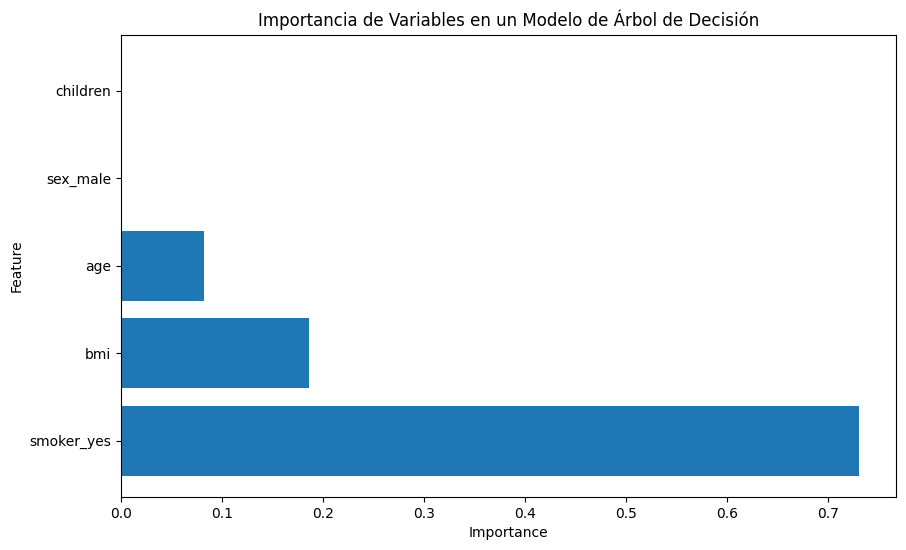

In [38]:
# Obtenemos la importancia de las variables
feature_importance = modelo_ArbolDecisionRegres.feature_importances_

# Creamos un DataFrame para visualizar las importancias junto con los nombres de las variables
feature_names = x_train.drop(columns='const').columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Ordenamos por importancia descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Importancia de Variables en un Modelo de Árbol de Decisión')
plt.show()

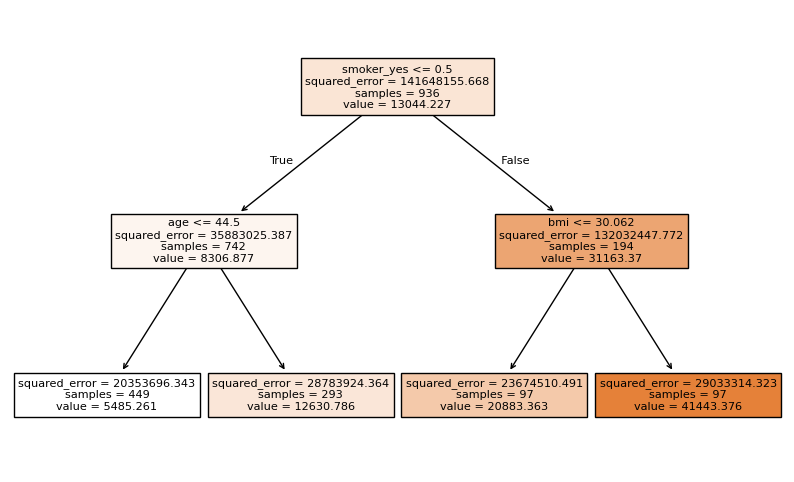

In [39]:
#import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 6))
plot_tree(modelo_ArbolDecisionRegres, filled=True, feature_names=x_train.drop(columns='const').columns)
plt.show()

In [40]:
## Ajustar el modelo de regresión lineal
#modelo_OLS = sm.OLS(y_train, x_train).fit()
#
## Resumen del modelo
#print(modelo_OLS.summary())

In [41]:
# ajustamos el indice en la data de test
x_test.reset_index(drop=True, inplace=True)

In [42]:
# calculamos predicción

## Regresión Lineal (Mínimos cuadrados ordinarios)
#print('Predicción Regresión Lineal - OLS')
#y_pred_OLS = modelo_OLS.predict(x_test)
#print(y_pred_OLS.head(2))

# Árbol de Decisión para Regresión
print('Predicción Árbol de Decisión - Regresión')
y_pred_ArbolDecisionRegres = modelo_ArbolDecisionRegres.predict(x_test.drop(columns='const'))
y_pred_ArbolDecisionRegres = pd.DataFrame(y_pred_ArbolDecisionRegres)
print(y_pred_ArbolDecisionRegres.head(2))

Predicción Árbol de Decisión - Regresión
              0
0  20883.363230
1  12630.786136


In [43]:
# Error Cuadratico Medio

## Regresión Lineal - OLS
#mse_OLS = mean_squared_error(y_test, y_pred_OLS)
#print(f"Error cuadrático medio (MSE)- Regresión Lineal OLS: {mse_OLS:.4f}")

# Árbol de Decisión - Regresión
mse_ArbolDecisionRegres = mean_squared_error(y_test, y_pred_ArbolDecisionRegres)
print(f"Error cuadrático medio (MSE)- Árbol de Decisión: {mse_ArbolDecisionRegres:.4f}")

#  Mientras menos mejor

Error cuadrático medio (MSE)- Árbol de Decisión: 28559045.8810


In [44]:
# Evaluación del modelo
print("MSE:", mean_squared_error(y_test, y_pred_ArbolDecisionRegres))
print("R²:", r2_score(y_test, y_pred_ArbolDecisionRegres))

MSE: 28559045.881028574
R²: 0.8187218357705547


In [ ]:
# Crear el regresor
reg = DecisionTreeRegressor(random_state=42)

# Definir la grilla de hiperparámetros a explorar
param_grid = {
    'max_depth': list(range(1, 20)),          # Profundidad máxima del árbol
    'min_samples_split': list(range(2, 10)),  # Mínimo de muestras para dividir un nodo
    'min_samples_leaf': list(range(1, 5))     # Mínimo de muestras en una hoja
}

# Realizar búsqueda en la grilla con validación cruzada
grid_search = GridSearchCV(reg, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

# Mejores hiperparámetros encontrados
best_params = grid_search.best_params_
print("Mejores hiperparámetros:", best_params)

Mejores hiperparámetros: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}


In [52]:
# Entrenar el modelo final con los mejores parámetros
#best_model = grid_search.best_estimator_

modelo_ArbolDecisionRegres = DecisionTreeRegressor(max_depth=4,min_samples_leaf=3,min_samples_split=2)
modelo_ArbolDecisionRegres.fit(x_train.drop(columns='const'), y_train) # omitimos la columna constante

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

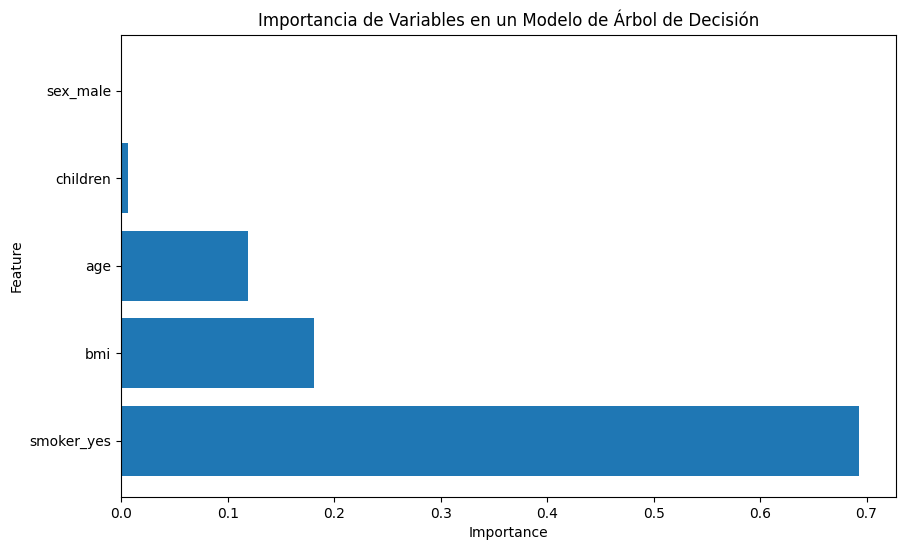

In [53]:
# Obtenemos la importancia de las variables
feature_importance = modelo_ArbolDecisionRegres.feature_importances_

# Creamos un DataFrame para visualizar las importancias junto con los nombres de las variables
feature_names = x_train.drop(columns='const').columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})

# Ordenamos por importancia descendente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graficamos la importancia de las variables
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Importancia de Variables en un Modelo de Árbol de Decisión')
plt.show()

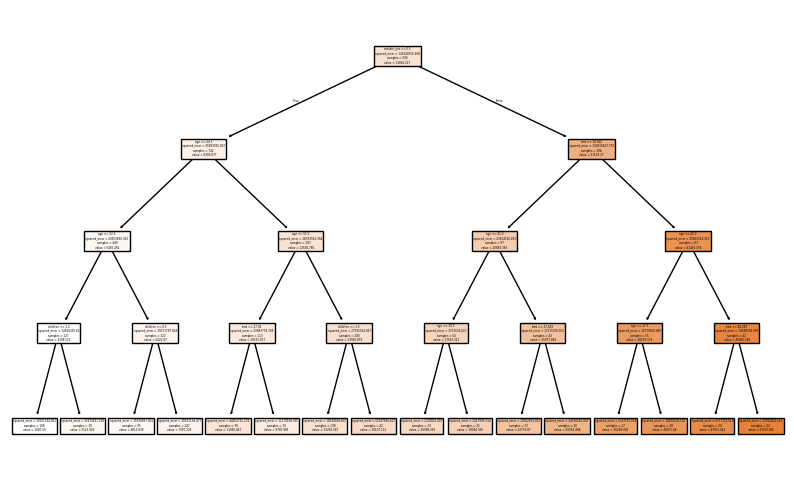

In [54]:
#import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 6))
plot_tree(modelo_ArbolDecisionRegres, filled=True, feature_names=x_train.drop(columns='const').columns)
plt.show()

In [55]:
from sklearn.tree import DecisionTreeRegressor, export_text

In [59]:
# Exportar el árbol en texto
tree_rules = export_text(modelo_ArbolDecisionRegres, feature_names=list(x_train.drop(columns='const').columns))
print(tree_rules)

|--- smoker_yes <= 0.50
|   |--- age <= 44.50
|   |   |--- age <= 22.50
|   |   |   |--- children <= 1.50
|   |   |   |   |--- value: [2683.59]
|   |   |   |--- children >  1.50
|   |   |   |   |--- value: [5523.93]
|   |   |--- age >  22.50
|   |   |   |--- children <= 0.50
|   |   |   |   |--- value: [4810.84]
|   |   |   |--- children >  0.50
|   |   |   |   |--- value: [7097.23]
|   |--- age >  44.50
|   |   |--- age <= 51.50
|   |   |   |--- bmi <= 27.94
|   |   |   |   |--- value: [11985.85]
|   |   |   |--- bmi >  27.94
|   |   |   |   |--- value: [9783.98]
|   |   |--- age >  51.50
|   |   |   |--- children <= 1.50
|   |   |   |   |--- value: [13281.59]
|   |   |   |--- children >  1.50
|   |   |   |   |--- value: [16107.11]
|--- smoker_yes >  0.50
|   |--- bmi <= 30.06
|   |   |--- age <= 41.00
|   |   |   |--- age <= 29.50
|   |   |   |   |--- value: [16588.29]
|   |   |   |--- age >  29.50
|   |   |   |   |--- value: [19044.06]
|   |   |--- age >  41.00
|   |   |   |--- bmi 

In [46]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
import pandas as pd
import graphviz

In [48]:
x_train

,const,age,sex_male,smoker_yes,bmi,children
972,1.0,22,0,0,20.235,0
816,1.0,24,0,0,24.225,0
145,1.0,29,0,0,38.830,3
919,1.0,35,0,0,34.210,1
766,1.0,47,1,0,32.300,1
...,...,...,...,...,...,...
356,1.0,46,1,0,43.890,3
960,1.0,19,0,0,39.615,1
812,1.0,54,1,0,21.010,2
132,1.0,53,0,0,35.900,2


In [33]:
# calculamos predicción

## Regresión Lineal (Mínimos cuadrados ordinarios)
#print('Predicción Regresión Lineal - OLS')
#y_pred_OLS = modelo_OLS.predict(x_test)
#print(y_pred_OLS.head(2))

# Árbol de Decisión para Regresión
print('Predicción Árbol de Decisión - Regresión')
y_pred_ArbolDecisionRegres = modelo_ArbolDecisionRegres.predict(x_test.drop(columns='const'))
y_pred_ArbolDecisionRegres = pd.DataFrame(y_pred_ArbolDecisionRegres)
print(y_pred_ArbolDecisionRegres.head(2))

Predicción Árbol de Decisión - Regresión
              0
0  16588.293091
1  13281.586887


In [36]:
# Evaluación del modelo
print("MSE:", mean_squared_error(y_test, y_pred_ArbolDecisionRegres))
print("R²:", r2_score(y_test, y_pred_ArbolDecisionRegres))

MSE: 25888107.168649968
R²: 0.8356755837552164
